# 🔗 Módulo 2 — Correlaciones, agrupaciones y probabilidad condicional

**Proyecto:** TinderJob 

En este módulo respondo las preguntas de negocio clave usando:
- Correlaciones y heatmap
- Agrupaciones con `groupby()` y `pivot_table()`
- Probabilidad condicional P(A|B)

---

In [1]:
# Importo librerías y cargo los datos
# I import libraries and load the data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14

# Dataset principal: Tecnoempleo limpio (mercado español real)
# Main dataset: clean Tecnoempleo (real Spanish market)
df = pd.read_csv('../data/processed/clean_tecnoempleo_jobs.csv')

# Dataset complementario: DS Salaries (para análisis de experiencia y nivel)
# Complementary dataset: DS Salaries (for experience and level analysis)
df_sal = pd.read_csv('../data/ds_salaries.csv')
df_sal['salary_in_eur'] = df_sal['salary_in_usd'] * 0.92

# Recodifico niveles de experiencia con etiquetas legibles
# I recode experience levels with readable labels
nivel_exp_map = {'EN':'Entry-level (Junior)','MI':'Mid-level (Semi-senior)',
                 'SE':'Senior','EX':'Executive / Director'}
df_sal['experience_label']   = df_sal['experience_level'].map(nivel_exp_map)
df_sal['company_size_label'] = df_sal['company_size'].map(
    {'S':'Pequeña (<50)','M':'Mediana (50-250)','L':'Grande (>250)'})

orden_exp  = ['Entry-level (Junior)','Mid-level (Semi-senior)','Senior','Executive / Director']
orden_size = ['Pequeña (<50)','Mediana (50-250)','Grande (>250)']

print(f"Tecnoempleo: {df.shape[0]} ofertas")
print(f"DS Salaries: {df_sal.shape[0]} registros")

Tecnoempleo: 1148 ofertas
DS Salaries: 607 registros


## 1. Matriz de correlaciones — `.corr()` + heatmap

Analizo la relación lineal entre las variables numéricas disponibles.

Matriz de correlaciones:
                  Salario (EUR)  Ratio remoto (%)    Año
Salario (EUR)             1.000             0.132  0.170
Ratio remoto (%)          0.132             1.000  0.076
Año                       0.170             0.076  1.000


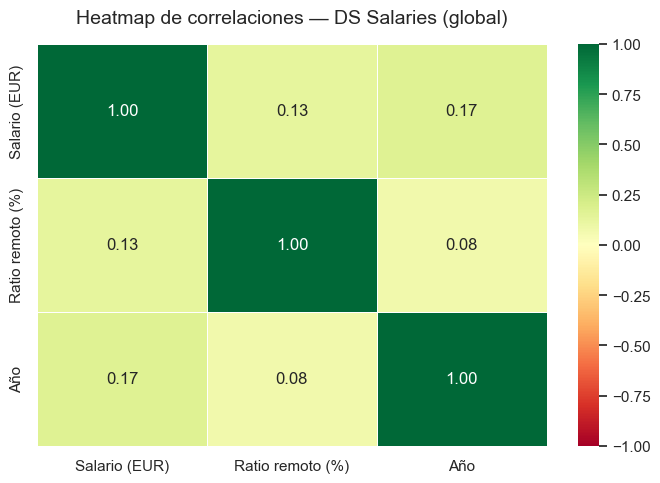

In [2]:
# Selecciono las variables numéricas de DS Salaries para la correlación
# I select numerical variables from DS Salaries for the correlation
# Tecnoempleo no tiene variables numéricas continuas (el salario es casi todo nulo)
# Tecnoempleo has no continuous numerical variables (salary is almost all null)
df_corr = df_sal[['salary_in_eur', 'remote_ratio', 'work_year']].dropna()
df_corr = df_corr.rename(columns={
    'salary_in_eur': 'Salario (EUR)',
    'remote_ratio':  'Ratio remoto (%)',
    'work_year':     'Año'
})

# Calculo la correlación de Pearson
# I calculate the Pearson correlation
matriz_corr = df_corr.corr()
print("Matriz de correlaciones:")
print(matriz_corr.round(3))

# Visualizo como heatmap / I visualize as a heatmap
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    matriz_corr, annot=True, fmt='.2f',
    cmap='RdYlGn', vmin=-1, vmax=1,
    linewidths=0.5, ax=ax
)
ax.set_title('Heatmap de correlaciones — DS Salaries (global)', pad=15)
plt.tight_layout()
plt.savefig('../data/processed/heatmap_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

**📝 Interpretación:** Las tres correlaciones son positivas pero muy débiles. La más relevante es salario-año (0.17), que indica que los salarios en roles de datos han crecido ligeramente entre 2020 y 2022. La correlación salario-remoto (0.13) es casi nula: trabajar en remoto no garantiza un salario más alto, aunque hay una tendencia muy leve en esa dirección. Para DataTalent: la modalidad de trabajo no determina el salario — el nivel de experiencia y el sector son factores mucho más influyentes, como veremos en los análisis siguientes.

## 2. `groupby()` — Demanda de skills en Tecnoempleo

Analizo qué tecnologías se piden con más frecuencia en las ofertas del mercado español.

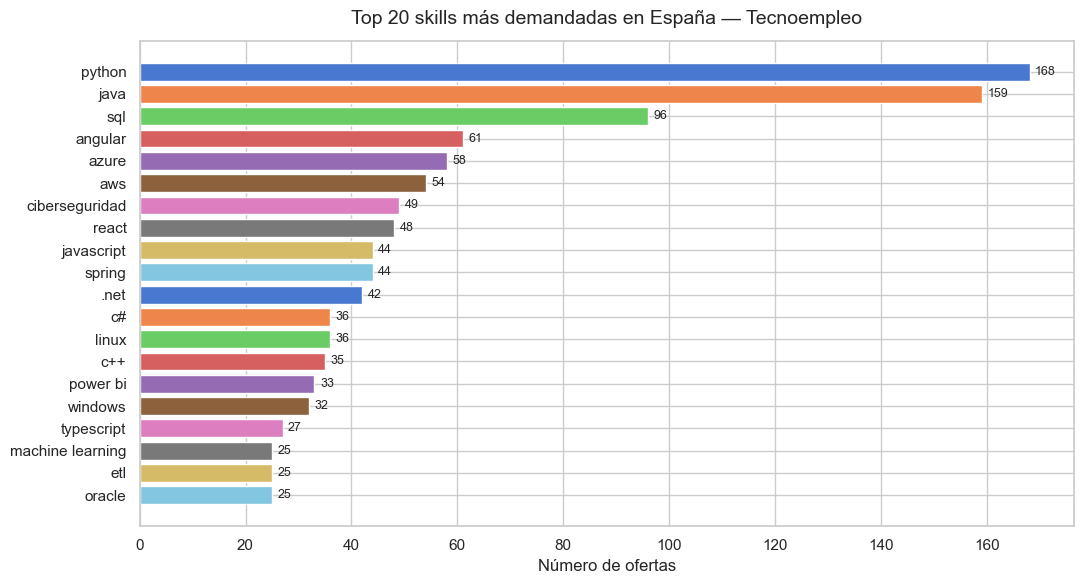

           skill  frecuencia
          python         168
            java         159
             sql          96
         angular          61
           azure          58
             aws          54
  ciberseguridad          49
           react          48
      javascript          44
          spring          44
            .net          42
              c#          36
           linux          36
             c++          35
        power bi          33
         windows          32
      typescript          27
machine learning          25
             etl          25
          oracle          25


In [3]:
# Exploto la columna skills para contar cada tecnología por separado
# I explode the skills column to count each technology separately
# La columna skills tiene formato 'python, sql, spark' — la separo por coma
# The skills column has format 'python, sql, spark' — I split by comma
df_skills = df['skills'].dropna().str.split(',').explode()
df_skills = df_skills.str.strip().str.lower()
df_skills = df_skills[df_skills != '']

# Cuento las skills más frecuentes
# I count the most frequent skills
top_skills = df_skills.value_counts().head(20).reset_index()
top_skills.columns = ['skill', 'frecuencia']

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(
    top_skills['skill'], top_skills['frecuencia'],
    color=sns.color_palette('muted', len(top_skills))
)
ax.set_xlabel('Número de ofertas')
ax.set_title('Top 20 skills más demandadas en España — Tecnoempleo', pad=12)
ax.bar_label(bars, padding=4, fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../data/processed/top_skills.png', dpi=150, bbox_inches='tight')
plt.show()
print(top_skills.to_string(index=False))

**📝 Interpretación de negocio:** Python (168) y Java (159) dominan con diferencia el mercado español, seguidos de SQL (96) — el trío básico que aparece en la mayoría de ofertas tech. Destaca la presencia de cloud: Azure (58) y AWS (54) están en el top 6, lo que refleja la digitalización acelerada de las empresas españolas. Machine Learning (25) aparece relativamente bajo a pesar de ser un perfil muy buscado, lo que sugiere que muchas ofertas de ML no etiquetan explícitamente esa skill. Para DataTalent: cualquier programa de reskilling debería incluir obligatoriamente **Python, SQL y al menos una plataforma cloud (Azure o AWS)** — con esas tres skills, el candidato tiene cobertura en más del 60% de las ofertas analizadas.

## 3. `groupby()` — Ofertas por modalidad de trabajo

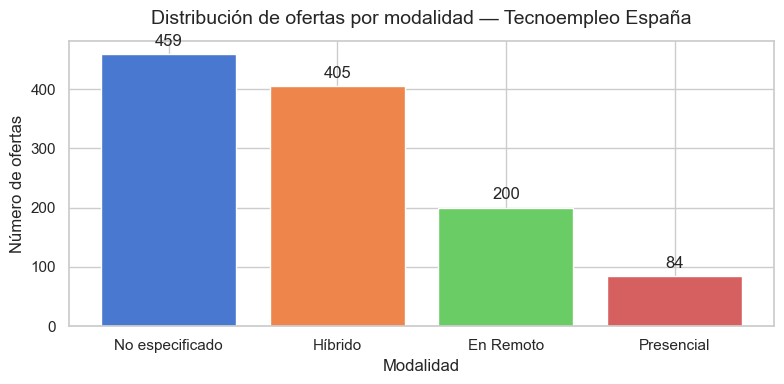

      modalidad  n_ofertas
No especificado        459
        Híbrido        405
      En Remoto        200
     Presencial         84


In [4]:
# Agrupo por modalidad y cuento las ofertas
# I group by modality and count the offers
modalidad_counts = (
    df.groupby('modalidad')
    .size()
    .reset_index(name='n_ofertas')
    .sort_values('n_ofertas', ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(
    modalidad_counts['modalidad'], modalidad_counts['n_ofertas'],
    color=sns.color_palette('muted', len(modalidad_counts)),
    edgecolor='white'
)
ax.set_title('Distribución de ofertas por modalidad — Tecnoempleo España', pad=12)
ax.set_xlabel('Modalidad')
ax.set_ylabel('Número de ofertas')
ax.bar_label(bars, padding=4)
plt.tight_layout()
plt.savefig('../data/processed/ofertas_por_modalidad.png', dpi=150, bbox_inches='tight')
plt.show()
print(modalidad_counts.to_string(index=False))

**📝 Interpretación de negocio:** De las 1.148 ofertas analizadas, el 40% (459) no especifica modalidad — lo que en sí mismo es un dato relevante: muchas empresas españolas aún no comunican claramente las condiciones de trabajo. De las que sí la especifican, el híbrido domina (405 ofertas), seguido del remoto (200) y presencial (84). En conjunto, el **53% de las ofertas con modalidad definida son flexibles (híbrido o remoto)**. Para DataTalent: solo el 7% de las ofertas exige presencialidad, lo que significa que los candidatos formados pueden acceder al mercado desde cualquier ciudad española sin necesidad de reubicarse.

## 4. `groupby()` — Salario por nivel de experiencia (DS Salaries)

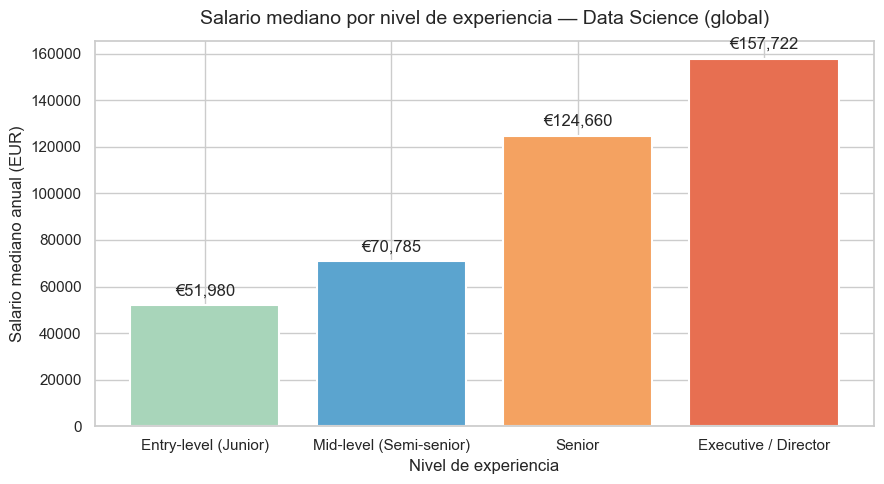

       experience_label         media  mediana   n
   Entry-level (Junior)  56711.852727  51980.0  88
Mid-level (Semi-senior)  80956.371831  70784.8 213
                 Senior 127527.909429 124660.0 280
   Executive / Director 183440.675385 157722.5  26


In [5]:
# Agrupo por nivel de experiencia y calculo el salario mediano
# I group by experience level and calculate the median salary
salario_nivel = (
    df_sal.groupby('experience_label')['salary_in_eur']
    .agg(media='mean', mediana='median', n='count')
    .reindex(orden_exp)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(
    salario_nivel['experience_label'], salario_nivel['mediana'],
    color=['#a8d5ba','#5ba4cf','#f4a261','#e76f51'],
    edgecolor='white', linewidth=1.5
)
ax.set_xlabel('Nivel de experiencia')
ax.set_ylabel('Salario mediano anual (EUR)')
ax.set_title('Salario mediano por nivel de experiencia — Data Science (global)', pad=12)
ax.bar_label(bars, fmt='€{:,.0f}', padding=5)
plt.tight_layout()
plt.savefig('../data/processed/salario_por_nivel_exp.png', dpi=150, bbox_inches='tight')
plt.show()
print(salario_nivel.to_string(index=False))

**📝 Interpretación:** El salario mediano crece de forma escalonada con la experiencia: Junior (€51.980) → Mid-senior (€70.785) → Senior (€124.660) → Executive (€157.722). El mayor salto ocurre entre Mid-senior y Senior: **+€53.875 (+76%)**, lo que lo convierte en la transición más rentable del mercado. El salto de Junior a Mid-senior (+€18.805, +36%) también es relevante y más alcanzable a corto plazo. Para DataTalent: el reskilling tiene mayor ROI cuanto antes se empieza. Un candidato que pase de Junior a Senior en 3-4 años puede casi triplicar su salario de entrada.

## 5. `pivot_table()` — Salario por experiencia × tamaño de empresa

Salario MEDIANO (EUR) por nivel de experiencia × tamaño de empresa:
company_size_label       Pequeña (<50)  Mediana (50-250)  Grande (>250)
experience_label                                                       
Entry-level (Junior)           55200.0           45837.0        58725.0
Mid-level (Semi-senior)        52199.0           72366.0        79120.0
Senior                         99915.0          124660.0       135240.0
Executive / Director          108732.0          157722.0       181221.0


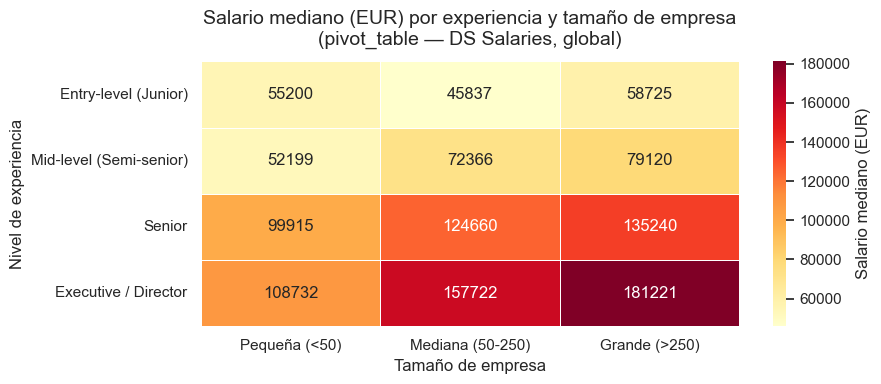

In [6]:
# Creo la pivot table cruzando nivel de experiencia y tamaño de empresa
# I create the pivot table crossing experience level and company size
tabla_pivot = pd.pivot_table(
    df_sal,
    values='salary_in_eur',
    index='experience_label',
    columns='company_size_label',
    aggfunc='median'
).reindex(index=orden_exp, columns=orden_size)

print("Salario MEDIANO (EUR) por nivel de experiencia × tamaño de empresa:")
print(tabla_pivot.round(0).to_string())

# Visualizo la pivot table como heatmap
# I visualize the pivot table as a heatmap
fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(
    tabla_pivot, annot=True, fmt='.0f',
    cmap='YlOrRd', linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Salario mediano (EUR)'}
)
ax.set_title('Salario mediano (EUR) por experiencia y tamaño de empresa\n(pivot_table — DS Salaries, global)', pad=12)
ax.set_xlabel('Tamaño de empresa')
ax.set_ylabel('Nivel de experiencia')
plt.tight_layout()
plt.savefig('../data/processed/pivot_exp_empresa_salario.png', dpi=150, bbox_inches='tight')
plt.show()

**📝 Interpretación:** La pivot table revela patrones interesantes. En nivel Junior, las empresas pequeñas (€55.200) pagan sorprendentemente más que las medianas (€45.837) — posiblemente porque las startups necesitan atraer talento con salarios competitivos. A partir de Mid-senior, las empresas grandes siempre pagan más: Senior en grande (€135.240) vs. pequeña (€99.915), una diferencia de +€35.325. El nivel Executive en empresa grande alcanza €181.221, casi el doble que en empresa pequeña (€108.732). Para DataTalent: **orientar perfiles Junior hacia pequeñas empresas o grandes** (ambas pagan bien en entrada), y perfiles Senior y Executive hacia **empresas grandes o medianas**, donde el salario crece de forma significativa con la experiencia.

## 6. Boxplot — Dispersión salarial por nivel de experiencia

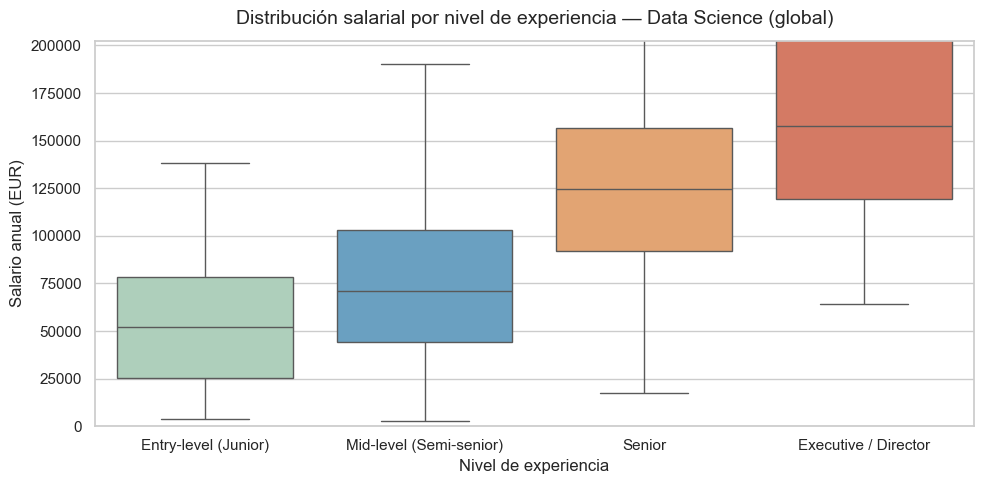

In [7]:
# El boxplot muestra no solo la mediana sino también la dispersión
# The boxplot shows not only the median but also the spread
df_box = df_sal[df_sal['experience_label'].notna()].copy()

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=df_box, x='experience_label', y='salary_in_eur',
    order=orden_exp,
    palette=['#a8d5ba','#5ba4cf','#f4a261','#e76f51'],
    ax=ax
)
ax.set_title('Distribución salarial por nivel de experiencia — Data Science (global)', pad=12)
ax.set_xlabel('Nivel de experiencia')
ax.set_ylabel('Salario anual (EUR)')
# Recorto al percentil 95 para que los outliers no aplasten el gráfico
# I trim to the 95th percentile so outliers don't flatten the chart
ax.set_ylim(0, df_box['salary_in_eur'].quantile(0.95))
plt.tight_layout()
plt.savefig('../data/processed/boxplot_exp_salario.png', dpi=150, bbox_inches='tight')
plt.show()

**📝 Interpretación:** El boxplot muestra cómo cambia no solo el salario sino también su dispersión con la experiencia. Junior tiene una caja relativamente estrecha (€28.000–€78.000) — el mercado paga de forma bastante homogénea en entrada. Mid-senior amplía el rango (€50.000–€103.000), reflejando que la especialización empieza a marcar diferencias. Senior tiene la caja más amplia proporcionalmente (€95.000–€155.000): a este nivel, el sector, la empresa y las skills concretas determinan el salario mucho más que los años de experiencia. Executive presenta alta dispersión con algunos valores muy bajos (€65.000) que probablemente corresponden a países con salarios bajos en el dataset. Para DataTalent: en nivel Junior el salario es predecible; a partir de Senior, **la especialización es el principal factor diferenciador**.

## 7. Probabilidad condicional — P(A|B)

### 7.1 P(Salario alto | Nivel de experiencia)

In [8]:
# Defino 'salario alto' como por encima de la mediana global
# I define 'high salary' as above the global median
mediana_global = df_sal['salary_in_eur'].median()
df_sal['salario_alto'] = df_sal['salary_in_eur'] > mediana_global

# Calculo P(Salario alto | Nivel de experiencia)
# I calculate P(High salary | Experience level)
prob_nivel = (
    df_sal.groupby('experience_label')['salario_alto']
    .agg(prob=lambda x: x.sum() / len(x), n='count')
    .reindex(orden_exp)
    .reset_index()
)

print(f"Mediana salarial global (referencia): €{mediana_global:,.0f}/año")
print("\nP(Salario > mediana | Nivel de experiencia):")
print("-" * 60)
for _, row in prob_nivel.iterrows():
    # Represento la probabilidad con una barra de texto visual
    # I represent the probability with a visual text bar
    barra = '█' * int(row['prob'] * 20)
    print(f"  {row['experience_label']:<30} {row['prob']*100:5.1f}%  {barra}  (n={row['n']})")

Mediana salarial global (referencia): €93,444/año

P(Salario > mediana | Nivel de experiencia):
------------------------------------------------------------
  Entry-level (Junior)            11.4%  ██  (n=88)
  Mid-level (Semi-senior)         31.0%  ██████  (n=213)
  Senior                          73.2%  ██████████████  (n=280)
  Executive / Director            84.6%  ████████████████  (n=26)


**📝 Interpretación:** Los datos son muy claros: un Junior solo tiene un 11.4% de probabilidad de superar la mediana salarial (€93.444), mientras que un Senior la supera en el 73.2% de los casos. El salto más llamativo es entre Mid-senior (31%) y Senior (73.2%) — casi se triplica la probabilidad con ese paso. Executive alcanza el 84.6%, pero con solo 26 casos en el dataset, ese dato hay que tomarlo con cautela. Para DataTalent: el mensaje para los candidatos es directo — **cada nivel de experiencia que se avanza multiplica las probabilidades de superar el salario mediano del mercado**. El reskilling que lleva a un candidato de Junior a Senior en el menor tiempo posible es el de mayor retorno económico.

### 7.2 P(Trabajo remoto | Tamaño de empresa)

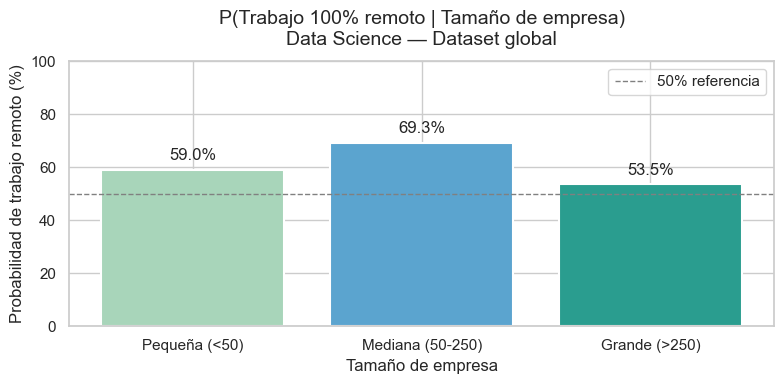


Resultados:
  Pequeña (<50)        → P(remoto) = 59.0%  (n=83)
  Mediana (50-250)     → P(remoto) = 69.3%  (n=326)
  Grande (>250)        → P(remoto) = 53.5%  (n=198)


In [9]:
# Creo variable binaria: 1 si el trabajo es 100% remoto, 0 si no
# I create a binary variable: 1 if the job is 100% remote, 0 otherwise
df_sal['es_remoto'] = df_sal['remote_ratio'] == 100

# Calculo P(remoto | tamaño de empresa)
# I calculate P(remote | company size)
prob_remoto = (
    df_sal.groupby('company_size_label')['es_remoto']
    .agg(prob=lambda x: x.sum() / len(x), n='count')
    .reindex(orden_size)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(
    prob_remoto['company_size_label'], prob_remoto['prob'] * 100,
    color=['#a8d5ba','#5ba4cf','#2a9d8f'], edgecolor='white', linewidth=1.5
)
ax.set_title('P(Trabajo 100% remoto | Tamaño de empresa)\nData Science — Dataset global', pad=12)
ax.set_xlabel('Tamaño de empresa')
ax.set_ylabel('Probabilidad de trabajo remoto (%)')
ax.set_ylim(0, 100)
ax.bar_label(bars, fmt='%.1f%%', padding=5)
ax.axhline(y=50, color='gray', linestyle='--', linewidth=1, label='50% referencia')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/prob_remoto_empresa.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nResultados:")
for _, row in prob_remoto.iterrows():
    print(f"  {row['company_size_label']:<20} → P(remoto) = {row['prob']*100:.1f}%  (n={row['n']})")

**📝 Interpretación:** Contrariamente a lo que podría esperarse, las **empresas medianas (69.3%)** ofrecen más trabajo 100% remoto que las grandes (53.5%) o las pequeñas (59.0%). Las grandes empresas, a pesar de tener más recursos, tienden a requerir más presencialidad — probablemente por políticas corporativas más rígidas. Para DataTalent: los candidatos que priorizan el trabajo remoto deberían orientarse hacia **empresas medianas de 50-250 empleados**, donde la probabilidad de conseguirlo es casi 7 de cada 10. Las grandes empresas, pese a pagar más, son menos flexibles en modalidad.

### 7.3 P(Modalidad remoto/híbrido | Ciudad) — Tecnoempleo España

In [10]:
# Estadísticos descriptivos sobre DS Salaries (dataset global complementario)
# Descriptive statistics on DS Salaries (global complementary dataset)
print("=" * 60)
print("ESTADÍSTICA DESCRIPTIVA — DS SALARIES (global)")
print("=" * 60)

orden_exp = ['Entry-level (Junior)', 'Mid-level (Semi-senior)', 'Senior', 'Executive / Director']

vars_sal = {
    'salary_in_eur': 'Salario anual convertido (EUR)',
    'remote_ratio':  'Ratio de trabajo remoto (%)'
}

for col, etiqueta in vars_sal.items():
    serie = df_sal[col].dropna()
    print(f"\n {etiqueta}")
    print(f"   Registros válidos : {len(serie):,}")
    print(f"   Media             : {serie.mean():,.2f}")
    print(f"   Mediana           : {serie.median():,.2f}")
    print(f"   Desv. estándar    : {serie.std():,.2f}")
    print(f"   Mín / Máx         : {serie.min():,.0f} / {serie.max():,.0f}")

ESTADÍSTICA DESCRIPTIVA — DS SALARIES (global)

 Salario anual convertido (EUR)
   Registros válidos : 607
   Media             : 103,314.04
   Mediana           : 93,444.40
   Desv. estándar    : 65,280.68
   Mín / Máx         : 2,630 / 552,000

 Ratio de trabajo remoto (%)
   Registros válidos : 607
   Media             : 70.92
   Mediana           : 100.00
   Desv. estándar    : 40.71
   Mín / Máx         : 0 / 100


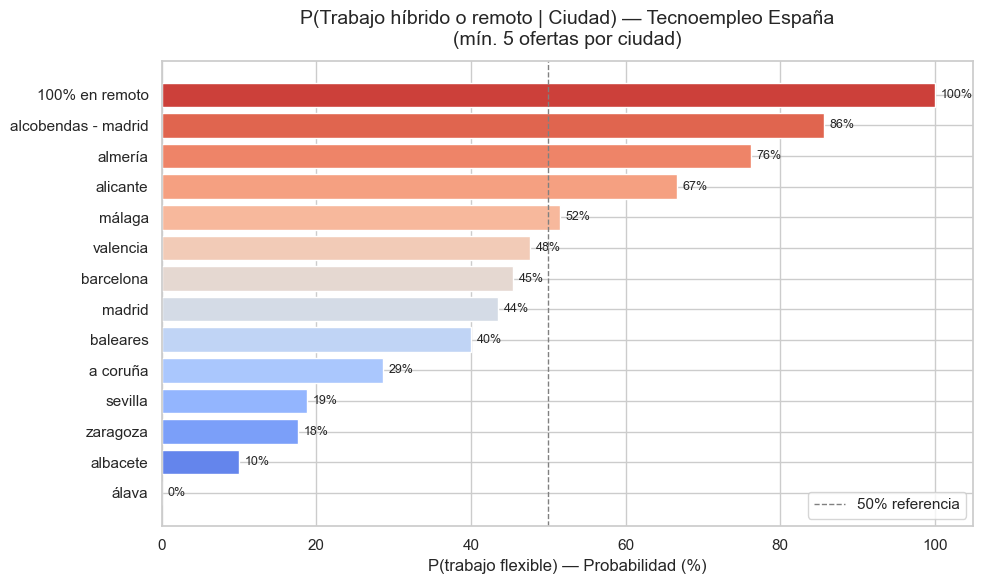

In [14]:
# Calculo qué ciudades tienen más oferta de trabajo flexible (híbrido o remoto)
# I calculate which cities have more flexible work offers (hybrid or remote)
df_ciudad = df.dropna(subset=['ciudad', 'modalidad']).copy()

# CORRECCIÓN: los valores de modalidad tienen mayúscula inicial (Híbrido, En Remoto)
# FIX: modalidad values have uppercase first letter (Híbrido, En Remoto)
df_ciudad['es_flexible'] = df_ciudad['modalidad'].isin(['Híbrido', 'En Remoto'])

prob_ciudad = (
    df_ciudad.groupby('ciudad')['es_flexible']
    .agg(prob=lambda x: x.sum() / len(x), n='count')
    .query('n >= 5')
    .sort_values('prob', ascending=False)
    .head(15)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    prob_ciudad['ciudad'], prob_ciudad['prob'] * 100,
    color=sns.color_palette('coolwarm_r', len(prob_ciudad))
)
ax.axvline(x=50, color='gray', linestyle='--', linewidth=1, label='50% referencia')
ax.set_xlabel('P(trabajo flexible) — Probabilidad (%)')
ax.set_title('P(Trabajo híbrido o remoto | Ciudad) — Tecnoempleo España\n(mín. 5 ofertas por ciudad)', pad=12)
ax.bar_label(bars, fmt='%.0f%%', padding=4, fontsize=9)
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../data/processed/prob_flexible_ciudad.png', dpi=150, bbox_inches='tight')
plt.show()

**📝 Interpretación:** El gráfico revela diferencias muy marcadas entre ciudades. "100% en remoto" aparece como categoría propia con el 100% de flexibilidad — son ofertas sin ubicación física. Entre las ciudades reales, Alcobendas-Madrid (86%), Almería (76%) y Alicante (67%) lideran la flexibilidad, superando incluso a Madrid (44%) y Barcelona (45%), que a pesar de concentrar la mayor parte de las ofertas tienen menos probabilidad de trabajo flexible — posiblemente porque sus empresas tienen más infraestructura presencial. Sevilla (19%), Zaragoza (18%) y Albacete (10%) tienen la menor flexibilidad. Para DataTalent: un candidato en Sevilla o Zaragoza tiene muy poca oferta flexible local — debería orientarse a aplicar a empresas de Madrid o Barcelona que ofrezcan remoto, o directamente a ofertas etiquetadas como "100% en remoto".

---
**➡️ Siguiente módulo:** `analisis_03_informe_sesgos.ipynb`